# TF-IDF Clásico

En este notebook implementamos un clasificador de texto para predecir la década de origen de textos históricos en español. Se utiliza TF-IDF sobre un vocabulario de palabras (unigramas) como representación del texto y Regresión Logística como modelo de clasificación. Este enfoque sirve como línea base del proyecto.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 2. Carga de los datos

Cargamos el conjunto de entrenamiento y el de evaluación por separado.

In [2]:
df = pd.read_csv('train.csv')
df_eval = pd.read_csv('eval.csv')

In [3]:
df.head()

,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


In [4]:
df.shape

(31403, 2)

## 3. Exploración del conjunto de datos

Revisamos la distribución de la variable objetivo y la calidad general del conjunto.

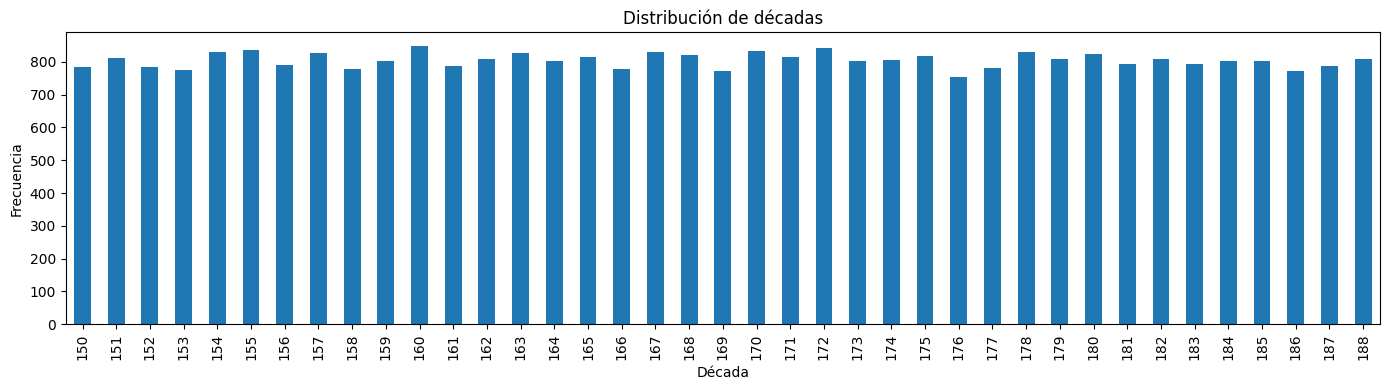

In [5]:
df['decade'].value_counts().sort_index().plot(
    kind='bar', figsize=(14, 4), title='Distribución de décadas'
)
plt.xlabel('Década')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [6]:
def reporte_calidad(df):
    reporte_de_cualidad = {
        'Total records': len(df),
        'duplicated record': df.duplicated().sum(),
        'missing values': df.isnull().sum().to_dict(),
        'data types': df.dtypes.astype(str).to_dict(),
    }
    return reporte_de_cualidad

print(reporte_calidad(df))

{'Total records': 31403, 'duplicated record': 34, 'missing values': {'text': 0, 'decade': 0}, 'data types': {'text': 'object', 'decade': 'int64'}}


## 4. Preprocesamiento del texto

Pasamos el texto a minúsculas y eliminamos caracteres que no sean letras del español. Esto reduce el ruido de puntuación, números y símbolos de digitalización, sin destruir las palabras arcaicas que resultan informativas para distinguir épocas. También eliminamos los registros duplicados antes de entrenar.

In [7]:
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df['texto_limpio'] = df['text'].apply(limpiar_texto)
df[['text', 'texto_limpio', 'decade']].head()

,text,texto_limpio,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,honorarias jubiladas dit ad pontem de poreft p...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",gone sus amigos sus clientes todo cuanto le ro...,182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",prefosen quemanera e per qualesfolpechas deuan...,157
3,Caistro el M a y o r a i .] Del ape...,caistro el m a y o r a i del apellido de cañro...,163
4,\nlos que panden macho ; y \notros en l...,los que panden macho y otros en la fu ña abund...,166


## 5. Partición de los datos

In [9]:
X = df['texto_limpio']
y = df['decade']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

Para conservar la misma proporción de clases en ambos conjuntos se usa `stratify=y`.

In [10]:
X_train.shape, X_val.shape

((25095,), (6274,))

## 6. Construcción del pipeline

El pipeline encadena la vectorización TF-IDF de palabras con la Regresión Logística. El solver `saga` es eficiente para datos de alta dimensionalidad y dispersos como los vectores TF-IDF.

In [11]:
pipeline_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, solver='saga')),
])

## 7. Entrenamiento con búsqueda de hiperparámetros

Exploramos distintas configuraciones del vectorizador y del parámetro de regularización. El espacio de búsqueda cubre el tamaño del vocabulario, la frecuencia mínima de documento y el valor de `C`.

In [12]:
param_grid = {
    'tfidf__max_features': [20000, 50000],
    'tfidf__min_df': [1, 2],
    'tfidf__max_df': [0.95],
    'clf__C': [0.1, 1, 10],
}

In [13]:
kfold = KFold(n_splits=5, shuffle=True, random_state=0)
grid_tfidf = GridSearchCV(
    pipeline_tfidf, param_grid, cv=kfold, scoring='accuracy', n_jobs=-1
)

In [14]:
grid_tfidf.fit(X_train, y_train)

,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'tfidf__max_df': [0.95], 'tfidf__max_features': [20000, 50000], 'tfidf__min_df': [1, 2]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [15]:
print('Mejores hiperparámetros:', grid_tfidf.best_params_)
print('Mejor score CV (accuracy):', round(grid_tfidf.best_score_, 4))

Mejores hiperparámetros: {'clf__C': 10, 'tfidf__max_df': 0.95, 'tfidf__max_features': 50000, 'tfidf__min_df': 1}
Mejor score CV (accuracy): 0.1996


## 8. Evaluación del mejor modelo

Aplicamos el mejor pipeline encontrado sobre el conjunto de validación para medir el desempeño real del modelo.

In [16]:
best_model = grid_tfidf.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_val   = best_model.predict(X_val)

#### Comparación de rendimientos sobre entrenamiento y validación

In [17]:
print('Accuracy en entrenamiento:', round(accuracy_score(y_train, y_pred_train), 4))
print('Accuracy en validación:   ', round(accuracy_score(y_val,   y_pred_val),   4))
print('Mejor score CV (accuracy):', round(grid_tfidf.best_score_,                 4))

Accuracy en entrenamiento: 0.998
Accuracy en validación:    0.2094
Mejor score CV (accuracy): 0.1996


In [18]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

         150       0.69      0.71      0.70       157
         151       0.43      0.48      0.45       161
         152       0.67      0.57      0.62       157
         153       0.39      0.44      0.41       154
         154       0.40      0.47      0.43       166
         155       0.21      0.22      0.21       167
         156       0.39      0.39      0.39       158
         157       0.17      0.17      0.17       165
         158       0.21      0.24      0.22       155
         159       0.16      0.18      0.17       160
         160       0.09      0.09      0.09       170
         161       0.10      0.11      0.11       157
         162       0.15      0.15      0.15       162
         163       0.10      0.09      0.10       165
         164       0.17      0.15      0.16       161
         165       0.08      0.09      0.09       163
         166       0.10      0.08      0.09       156
         167       0.15    

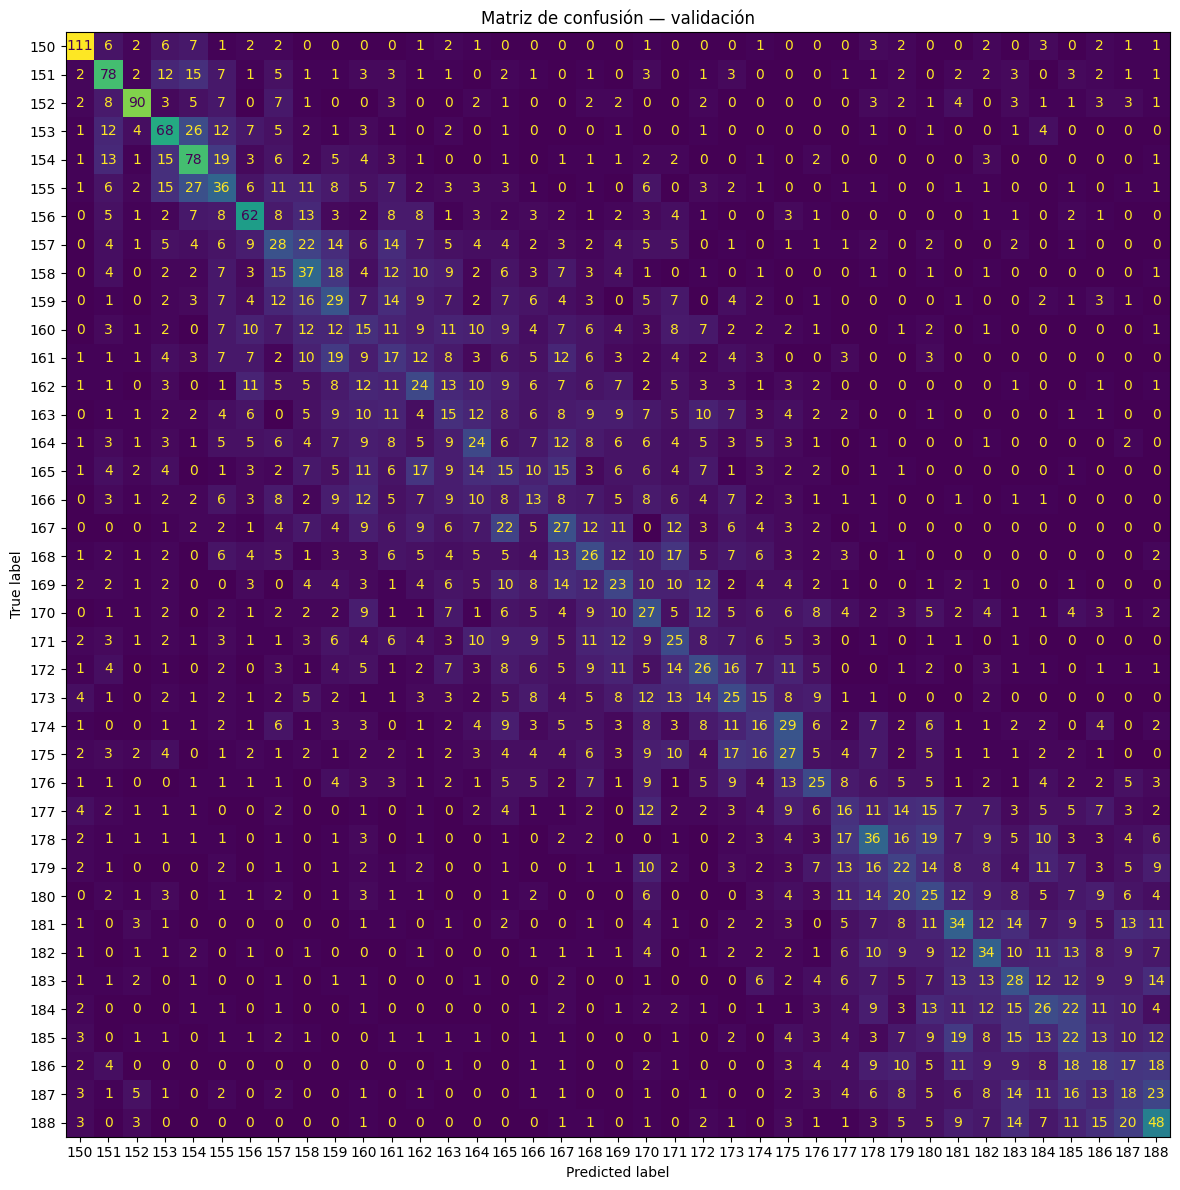

In [19]:
fig, ax = plt.subplots(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_val, ax=ax, colorbar=False)
plt.title('Matriz de confusión — validación')
plt.tight_layout()
plt.show()

## 9. Predicciones sobre eval.csv

Aplicamos la misma limpieza al conjunto de evaluación y generamos las predicciones con el mejor modelo.

In [20]:
df_eval['texto_limpio'] = df_eval['text'].apply(limpiar_texto)

y_eval_pred = best_model.predict(df_eval['texto_limpio'])

submission = pd.DataFrame({'id': df_eval['id'], 'answer': y_eval_pred})
submission.to_csv('submission_tfidf_clasico.csv', index=False)
submission.head()

,id,answer
0,0,174
1,1,179
2,2,150
3,3,173
4,4,153
